In [1]:
import torch
print(torch.cuda.get_device_name(0))
x = torch.randn(1000, 1000, device='cuda')
print('CUDA works:', (x @ x).sum().item() != 0)


Tesla T4
CUDA works: True


In [2]:
# 1. Environment, persistent storage, and dependencies.
import os, subprocess, sys, shutil

def run(cmd, what):
    """Fail at the point of failure. A quiet pip error here reappears ten
    minutes later as something baffling and unrelated."""
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print(r.stderr[-2000:])
        raise SystemExit(f'{what} failed (exit {r.returncode})')
    print(f'{what} OK')

ON_KAGGLE = os.path.isdir('/kaggle/working')
if ON_KAGGLE:
    PERSIST, REPO = '/kaggle/working/turnwave-ckpt', '/kaggle/working/turnwave'
else:
    from google.colab import drive
    drive.mount('/content/drive')
    PERSIST, REPO = '/content/drive/MyDrive/turnwave', '/content/turnwave'
os.makedirs(PERSIST, exist_ok=True)

if not os.path.isdir(REPO):
    run(['git', 'clone', '-q', 'https://github.com/Nikhils-G/turnwave.git', REPO], 'clone')
%cd {REPO}
subprocess.run(['git', 'checkout', '--', '.']); subprocess.run(['git', 'pull', '-q'])

pip = [sys.executable, '-m', 'pip', 'install', '-q']
run(pip + ['--no-deps', '-e', '.'], 'turnwave')
run(pip + ['sentencepiece', 'soundfile', 'datasets', 'onnx', 'onnxruntime', 'onnxscript'], 'deps')

import torch
assert torch.cuda.is_available(), 'No GPU. Colab: Runtime > Change runtime type > T4.'
print(f'GPU {torch.cuda.get_device_name(0)} | checkpoints -> {PERSIST}')

clone OK
/kaggle/working/turnwave
turnwave OK
deps OK
GPU Tesla T4 | checkpoints -> /kaggle/working/turnwave-ckpt


In [3]:
import json, os

CACHE = 'data/audio_smartturn'
if os.path.exists(f'{CACHE}/manifest.json'):
    m = json.load(open(f'{CACHE}/manifest.json'))
    print('cache present:', {s['split']: s['examples'] for s in m['splits']})
else:
    !python scripts/build_audio_dataset.py --source smart-turn --out {CACHE} \
        --max-examples 100000 --max-eval-examples 8000

README.md: 3.26kB [00:00, 8.54MB/s]
train     : 100%|██████████████████████| 100000/100000 [08:26<00:00, 197.44ex/s]
README.md: 3.25kB [00:00, 12.7MB/s]
test      : 100%|███████████████████████████| 8000/8000 [01:33<00:00, 85.18ex/s]
train        100,000 examples from 100,000 rows (49,738 complete / 50,262 mid-turn, 49.7% positive)
validation     8,000 examples from  8,000 rows (4,013 complete / 3,987 mid-turn, 50.2% positive)
test           8,000 examples from  8,000 rows (3,939 complete / 4,061 mid-turn, 49.2% positive)
manifest: data/audio_smartturn/manifest.json
'[Errno 9] Bad file descriptor' thrown while requesting GET https://huggingface.co/datasets/pipecat-ai/smart-turn-data-v3.2-test/resolve/0500378e8ed6d38e37b016e24d261e8e6c6a6859/data/train-00005-of-00010.parquet
Retrying in 1s [Retry 1/5].
Fatal Python error: PyGILState_Release: auto-releasing thread-state, but no thread-state for this thread
Python runtime state: finalizing (tstate=0x0000000000b8a5b0)



In [4]:
import json
m = json.load(open('data/audio_smartturn/manifest.json'))
print({s['split']: s['examples'] for s in m['splits']}, '| source:', m['source'])


{'train': 100000, 'validation': 8000, 'test': 8000} | source: smart-turn


In [5]:
AUDIO_OUT = f'{PERSIST}/audio_eot_v2'
!python -m turnwave.train --task audio --cache {CACHE} --out {AUDIO_OUT} \
    --steps 8000 --batch-size 128 --lr 3e-4 --num-workers 2 --resume


device=cuda task=audio params=3.49M (trainable 3.49M) train=100000 val=8000
no checkpoint at /kaggle/working/turnwave-ckpt/audio_eot_v2/last.pt; starting fresh
step    250  lr 2.50e-04  train 0.5589  val 0.5385  acc 0.741  f1 0.696  ap 0.842
step    500  lr 3.00e-04  train 0.4611  val 0.4379  acc 0.798  f1 0.805  ap 0.850
step    750  lr 2.98e-04  train 0.4280  val 0.4101  acc 0.816  f1 0.831  ap 0.870
step   1000  lr 2.94e-04  train 0.4183  val 0.4247  acc 0.802  f1 0.824  ap 0.870
step   1250  lr 2.89e-04  train 0.4031  val 0.3873  acc 0.828  f1 0.843  ap 0.886
step   1500  lr 2.83e-04  train 0.3926  val 0.3766  acc 0.832  f1 0.842  ap 0.885
step   1750  lr 2.75e-04  train 0.3819  val 0.3889  acc 0.826  f1 0.830  ap 0.884
step   2000  lr 2.67e-04  train 0.3800  val 0.3791  acc 0.831  f1 0.836  ap 0.890
step   2250  lr 2.57e-04  train 0.3780  val 0.3726  acc 0.833  f1 0.845  ap 0.896
step   2500  lr 2.45e-04  train 0.3601  val 0.3672  acc 0.838  f1 0.848  ap 0.896
step   2750  lr 2.33

/kaggle/working/turnwave/turnwave/export.py:84: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
task=audio
  fp32  13.98 MB    4.34 ms  max prob delta 5.96e-08
  int8   3.54 MB   30.88 ms  max prob delta 1.05e-03
  ship: fp32 (7.1x faster)
parity OK
wrote /kaggle/working/turnwave-ckpt/audio_v2_curves.png  (best AP 0.9194 at step 6,000)


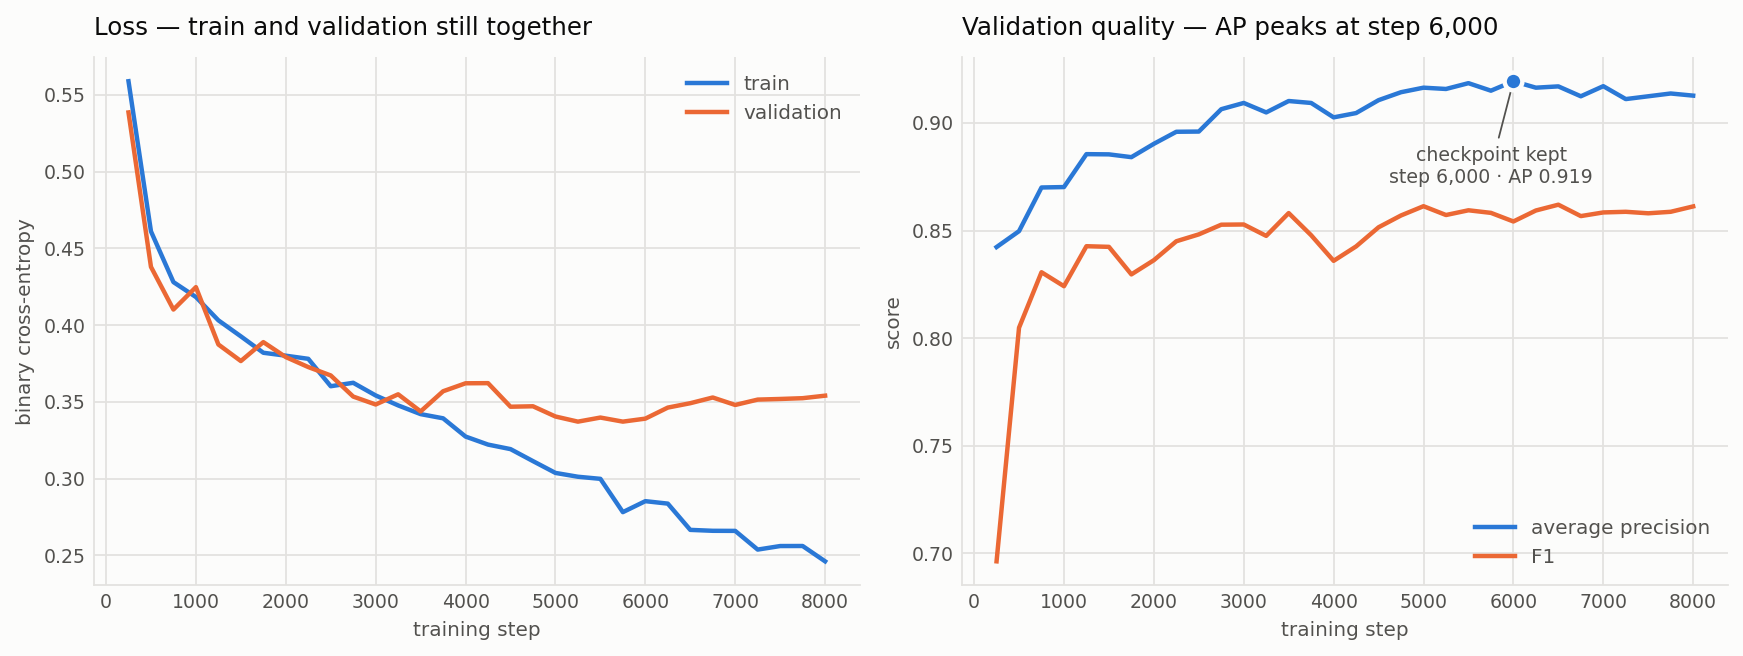

In [6]:
!python -m turnwave.export --ckpt {AUDIO_OUT}/best.pt --out-dir {PERSIST}/onnx
!python scripts/plot_training.py {AUDIO_OUT}/log.csv --out {PERSIST}/audio_v2_curves.png
from IPython.display import Image, display
display(Image(f'{PERSIST}/audio_v2_curves.png'))

In [7]:
# eot-bench pins numpy<2, so it is installed last and the runtime restarted
# after. Installing it earlier lets a later resolve pull numpy 2.x back in.
run([sys.executable, '-m', 'pip', 'install', '-q',
     'git+https://github.com/livekit/eot-bench', 'numpy<2'], 'eot-bench')
print('Now: Runtime > Restart session, then run the LAST cell only.')

eot-bench OK
Now: Runtime > Restart session, then run the LAST cell only.


In [ ]:
# Run this after the restart.
import os, numpy, shutil
ON_KAGGLE = os.path.isdir('/kaggle/working')
PERSIST = '/kaggle/working/turnwave-ckpt' if ON_KAGGLE else '/content/drive/MyDrive/turnwave'
REPO = '/kaggle/working/turnwave' if ON_KAGGLE else '/content/turnwave'
%cd {REPO}
assert numpy.__version__.startswith('1.'), f'numpy {numpy.__version__}: restart the runtime'
assert shutil.which('eot-harness'), 'harness missing: re-run the install cell'

os.makedirs('checkpoints/onnx', exist_ok=True)
os.makedirs('checkpoints/tokenizer', exist_ok=True)
shutil.copy(f'{PERSIST}/onnx/audio_eot.onnx', 'checkpoints/onnx/audio_eot.onnx')
BASE = 'https://github.com/Nikhils-G/turnwave/releases/download/models-v1'
!wget -q {BASE}/spm.model -O checkpoints/tokenizer/spm.model

os.environ['TURNWAVE_ONNX'] = 'checkpoints/onnx/audio_eot.onnx'
!eot-harness predict --path livekit/eot-bench-data --name all --split validation \
    --adapter turnwave.eot_bench_adapter:TurnWaveAudioOnlyAdapter --output-dir output

import glob
for p in glob.glob('output/**/predictions.parquet', recursive=True):
    !eot-harness compute-metrics --predictions "{p}" --output-dir "{os.path.dirname(p)}/metrics"
ROOT = 'output/livekit__eot-bench-data__validation__min_silence_100ms/en'
!eot-harness compare-models {ROOT}
!cp -r output {PERSIST}/eot_bench_v2